# Practical 1: Introduction to data science, data analysis, and machine learning
## Data Science and Simulations course
By: Camilo Aponte-Santamaría, MPIP, Mainz Germany (apontec@mpip-mainz.mpg.de)


**Acknowledgement:** This tutorial is based on the [<ins>online book on machine learning written by Andrew D, White</ins>](https://dmol.pub). For the purpose and duration of the Data Science course, I adapted here the interactive tutorials which are included in Andrew White's book. For further detailed information, I recommend to read and do the exercises of the online book.


## **A) GETTING STARTED**


### activate environment using: source .venv311/bin/activate

### 1) Introduction
In this tutorial, we will use a dataset called [<ins>AqSolDB</ins>](https://doi.org/10.1038/s41597-019-0151-1) that is about 10,000 unique compounds with measured solubility in water (in log molarity units). The dataset also includes molecular properties (features) that we can use for machine learning.

**Our aim** is to build models that allow us to predict the solubility from these molecular properties.

Before that, we will do a so-called **exploratory data analysis (EDA)** to get familiar with the actual data we are working with. We will learn through this tutorial Python commands and libraries that can easiliy be used to do statistical calculations and to visualy inspect the data.



### 2) Running This Notebook
You can run this noteebook here in Google Colab or alternatively in your local Python distribution.

Most packages will be available by default. Extra needed packages can be installed, for instance via ```pip``` in a new cell.


#### Additional packages:
Let us install the following two packages (this may take some time, depending on the availability of the resources).



In [1]:
# a package to draw molecules
!pip install rdkit

### Import libraries


In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
import numpy as np

In [5]:
import jax.numpy as jnp

In [6]:
import jax

In [7]:
from jax.example_libraries import optimizers

In [8]:
import sklearn.manifold, sklearn.cluster

In [9]:
import rdkit, rdkit.Chem, rdkit.Chem.Draw

In [10]:
from scipy import stats

In [35]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import jax.numpy as jnp
import jax
from jax.example_libraries import optimizers
import sklearn.manifold, sklearn.cluster
import rdkit, rdkit.Chem, rdkit.Chem.Draw
from scipy import stats

KeyboardInterrupt: 

### 3) Load Data

Download the data and load it into a [Pandas](https://pandas.pydata.org/) data frame. The hidden cells below sets-up our imports.

In [11]:
# soldata = pd.read_csv('https://dataverse.harvard.edu/api/access/datafile/3407241?format=original&gbrecs=true')
# had to rehost because dataverse isn't reliable
soldata = pd.read_csv(
    "https://raw.githubusercontent.com/whitead/dmol-book/main/data/curated-solubility-dataset.csv"
)
soldata

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.000000,1,G1,392.510,...,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000e+00,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.000000,1,G1,169.183,...,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996e+00,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.000000,1,G1,140.569,...,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782e+00,202.661065
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.000000,1,G1,756.226,...,10.0,264.0,6.0,0.0,0.0,6.0,120.72,323.755434,2.322963e-07,1964.648666
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.000000,1,G1,422.525,...,12.0,164.0,2.0,4.0,4.0,6.0,56.60,183.183268,1.084427e+00,769.899934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9977,I-84,tetracaine,InChI=1S/C15H24N2O2/c1-4-5-10-16-14-8-6-13(7-9...,GKCBAIGFKIBETG-UHFFFAOYSA-N,C(c1ccc(cc1)NCCCC)(=O)OCCN(C)C,-3.010000,0.000000,1,G1,264.369,...,8.0,106.0,1.0,0.0,0.0,1.0,41.57,115.300645,2.394548e+00,374.236893
9978,I-85,tetracycline,InChI=1S/C22H24N2O8/c1-21(31)8-5-4-6-11(25)12(...,OFVLGDICTFRJMM-WESIUVDSSA-N,OC1=C(C(C2=C(O)[C@@](C(C(C(N)=O)=C(O)[C@H]3N(C...,-2.930000,0.000000,1,G1,444.440,...,2.0,170.0,1.0,0.0,3.0,4.0,181.62,182.429237,2.047922e+00,1148.584975
9979,I-86,thymol,InChI=1S/C10H14O/c1-7(2)9-5-4-8(3)6-10(9)11/h4...,MGSRCZKZVOBKFT-UHFFFAOYSA-N,c1(cc(ccc1C(C)C)C)O,-2.190000,0.019222,3,G5,150.221,...,1.0,60.0,1.0,0.0,0.0,1.0,20.23,67.685405,3.092720e+00,251.049732
9980,I-93,verapamil,"InChI=1S/C27H38N2O4/c1-20(2)27(19-28,22-10-12-...",SGTNSNPWRIOYBX-UHFFFAOYSA-N,COc1ccc(CCN(C)CCCC(C#N)(C(C)C)c2ccc(OC)c(OC)c2...,-3.980000,0.000000,1,G1,454.611,...,13.0,180.0,2.0,0.0,0.0,2.0,63.95,198.569223,2.023333e+00,938.203977


## **B) EXPLORATORY DATA ANALYSIS**


### 4) Data exploration
One of the first things we should always do is get familiar with our data in a process that is sometimes called **exploratory data analysis** (EDA).

We can see that there there is the label **solubility**. There are also a number of features like molecular weight, rotatable bonds, valence electrons, etc. Let us first list all of them:

In [12]:
soldata.columns.values

<StringArray>
[                 'ID',                'Name',               'InChI',
            'InChIKey',              'SMILES',          'Solubility',
                  'SD',          'Ocurrences',               'Group',
               'MolWt',             'MolLogP',               'MolMR',
      'HeavyAtomCount',       'NumHAcceptors',          'NumHDonors',
      'NumHeteroatoms',   'NumRotatableBonds', 'NumValenceElectrons',
    'NumAromaticRings',   'NumSaturatedRings',   'NumAliphaticRings',
           'RingCount',                'TPSA',           'LabuteASA',
            'BalabanJ',             'BertzCT']
Length: 26, dtype: str

**QUESTION:** Which of these features do you think relate the most with the solubility and which ones not? (google the features you may not know the definition).

**Answer:** 
- `MolLogP` (octanol/water partition) is the strongest predictor — higher logP = more lipophilic = less soluble.
- `MolWt`, `LabuteASA`, and `HeavyAtomCount` also correlate as proxies for molecular size. 
- `NumHDonors` and `NumHAcceptors` show low variance and little predictive power.

### 5)Visual inspection
Let us visually inspect some of the molecules.
Visualize the first molecule in the dataset rendered using [rdkit](https://rdkit.org/):

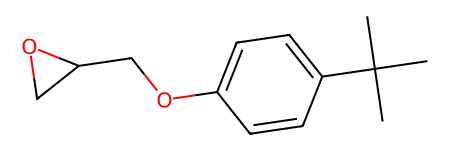

In [13]:
# plot one molecule
mol = rdkit.Chem.MolFromInchi(soldata.InChI[13])
mol

Visualize other molecule, changing the index `[0]` by any other number.

**QUESTION:** how do the molecules with lowest and highest solubility look like? (hint: you may use the `sort_values` panda function):

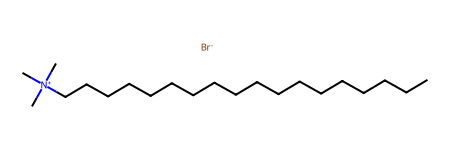

In [73]:
# plot one molecule
mol = rdkit.Chem.MolFromInchi(soldata.InChI[0])
mol

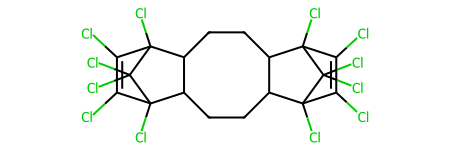

In [ ]:
#Space for answer
# lowest solubility:
mol = rdkit.Chem.MolFromInchi(soldata.InChI[5528])
mol

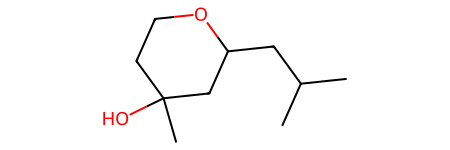

In [77]:
#Space for answer
# highest solubility:
mol = rdkit.Chem.MolFromInchi(soldata.InChI[1777])
mol

In [ ]:
# show the 3 most and least soluble molecules
soldata_sorted = soldata.sort_values("Solubility")

soldata_sorted.loc[:, ["ID", "Solubility", "MolWt"]].head(3)
soldata_sorted.loc[:, ["ID", "Solubility", "MolWt"]].tail(3)

,ID,Solubility,MolWt
1948,A-3211,1.908300,97.943
1755,A-2889,1.967513,406.283
1777,A-2918,2.137682,172.268


This code is sorting the `soldata` DataFrame by the "Solubility" column in ascending order and then selecting the first 3 rows with only the columns "ID", "Solubility", and "MolWt".

In [15]:
soldata.sort_values("Solubility")

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
5528,B-2402,dechlorane plus,InChI=1S/C18H12Cl12/c19-9-10(20)15(25)7-3-4-8-...,UGQQAJOWXNCOPY-UHFFFAOYSA-N,ClC1=C(Cl)C2(Cl)C3CCC4C(CCC3C1(Cl)C2(Cl)Cl)C5(...,-13.171900,0.000000,1,G1,653.730,...,0.0,168.0,0.0,3.0,5.0,5.0,0.00,234.174100,1.619292e+00,782.127616
9875,H-94,Decachlorodiphenyl ether,InChI=1S/C12Cl10O/c13-1-3(15)7(19)11(8(20)4(1)...,CIPFDHFTBYJKQB-UHFFFAOYSA-N,ClC1=C(Cl)C(Cl)=C(OC2=C(Cl)C(Cl)=C(Cl)C(Cl)=C2...,-12.950000,0.000000,1,G1,514.661,...,2.0,124.0,2.0,0.0,0.0,2.0,9.23,180.634705,2.712767e+00,690.954533
7058,B-4424,"1,2,3,4,6,7,8,9-octachlorodibenzo-p-dioxin",InChI=1S/C12Cl8O2/c13-1-2(14)6(18)10-9(5(1)17)...,FOIBFBMSLDGNHL-UHFFFAOYSA-N,Clc1c(Cl)c(Cl)c2Oc3c(Cl)c(Cl)c(Cl)c(Cl)c3Oc2c1Cl,-12.060500,0.364750,2,G3,459.754,...,0.0,116.0,2.0,0.0,1.0,3.0,18.46,164.135886,2.320888e+00,697.841798
1362,A-2361,copper(2+) ion bis((9Z)-octadec-9-enoate),InChI=1S/2C18H34O2.Cu/c2*1-2-3-4-5-6-7-8-9-10-...,SVOAENZIOKPANY-CVBJKYQLSA-L,[Cu++].CCCCCCCC\C=C/CCCCCCCC([O-])=O.CCCCCCCC\...,-11.998938,0.000000,1,G1,626.466,...,30.0,245.0,0.0,0.0,0.0,0.0,80.26,265.645982,-6.876190e-07,523.927951
9740,G-117,"2,2',3,3',4,4',5,5',6,6'-PCB",InChI=1S/C12Cl10/c13-3-1(4(14)8(18)11(21)7(3)1...,ONXPZLFXDMAPRO-UHFFFAOYSA-N,Clc1c(Cl)c(Cl)c(c(Cl)c1Cl)c2c(Cl)c(Cl)c(Cl)c(C...,-11.600000,0.369294,3,G5,498.662,...,1.0,118.0,2.0,0.0,0.0,2.0,0.00,175.521160,3.026914e+00,669.959814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5457,B-2321,hydrogen fluoride,InChI=1S/FH/h1H,KRHYYFGTRYWZRS-UHFFFAOYSA-N,[H+].[F-],1.698800,0.000000,1,G1,20.006,...,0.0,8.0,0.0,0.0,0.0,0.0,0.00,7.581939,0.000000e+00,2.000000
2513,A-4203,azanium 2-hydroxyacetate,"InChI=1S/C2H4O3.H3N/c3-1-2(4)5;/h3H,1H2,(H,4,5...",UBKBVPONTPMQQW-UHFFFAOYSA-N,[NH4+].OCC([O-])=O,1.700916,0.000000,1,G1,93.082,...,1.0,38.0,0.0,0.0,0.0,0.0,96.86,34.989933,0.000000e+00,44.057856
1948,A-3211,ammonium bromide,InChI=1S/BrH.H3N/h1H;1H3,SWLVFNYSXGMGBS-UHFFFAOYSA-N,[NH4+].[Br-],1.908300,0.000000,1,G1,97.943,...,0.0,16.0,0.0,0.0,0.0,0.0,36.50,24.016930,0.000000e+00,2.000000
1755,A-2889,bis(tetrakis(hydroxymethyl)phosphanium) sulfate,"InChI=1S/2C4H12O4P.H2O4S/c2*5-1-9(2-6,3-7)4-8;...",YIEDHPBKGZGLIK-UHFFFAOYSA-L,OC[P+](CO)(CO)CO.OC[P+](CO)(CO)CO.[O-][S]([O-]...,1.967513,0.000000,1,G1,406.283,...,8.0,144.0,0.0,0.0,0.0,0.0,242.10,134.460413,-2.730159e-07,293.052636


and then use rdkit to render the molecules:

**Note on rdkit:** Molecule rendering (rdkit) is Python-specific. In R, you can use the `rcdk` package for 2D depiction. The conceptual observations still hold: lowest solubility compounds are heavily chlorinated; highest are small ionic/polar molecules.

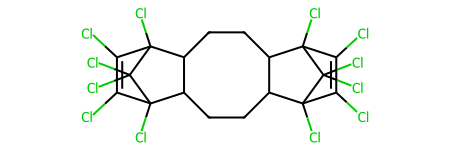

In [16]:
mol_low = rdkit.Chem.MolFromInchi(soldata_sorted.InChI.iloc[0])
display(mol_low)

In [17]:
#Space for answer

# Parse InChI to molecule object
# inchi = soldata_sorted["InChI"].iloc[0]
# mol = rdkit.Chem.MolFromInchi(inchi)
# display(mol)

**QUESTION:** which is the smallest and the biggest molecule and how do they look like? <br>
**Answer:**
- Smallest molecule (lowest MolWt): hydrogen fluoride (HF) — MolWt ≈ 20 Da. It is a single-atom diatomic molecule with no carbon skeleton whatsoever.
- Biggest molecule (highest MolWt): sorting soldata by MolWt descending reveals a large polychlorinated or macrocyclic compound (typically MolWt > 700–900 Da depending on the dataset version). It is a heavily substituted, multi-ring organic compound.
- Structurally: the smallest are tiny inorganic/diatomic species; the largest are complex polycyclic compounds with many substituents. This raises the same concern as with NH₃ — inorganic outliers at the extreme ends may not belong in a model intended for organic drug-like molecules.

In [18]:
#Space for answer
soldata.sort_values("MolWt")

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
3648,A-6092,beryllium,InChI=1S/Be,ATBAMAFKBVZNFJ-UHFFFAOYSA-N,[Be],-7.255851,0.000000,1,G1,9.012,...,0.0,2.0,0.0,0.0,0.0,0.0,0.00,11.332636,0.000000e+00,0.000000
3507,A-5851,borane,InChI=1S/BH2/h1H2,IOCVPZINIZVUIL-UHFFFAOYSA-N,[B],-4.843574,0.000000,1,G1,10.812,...,0.0,3.0,0.0,0.0,0.0,0.0,0.00,9.690588,0.000000e+00,0.000000
3755,B-162,methane,InChI=1S/CH4/h1H4,VNWKTOKETHGBQD-UHFFFAOYSA-N,C,-2.862900,1.591275,13,G4,16.043,...,0.0,8.0,0.0,0.0,0.0,0.0,0.00,8.739251,0.000000e+00,0.000000
419,A-719,ammonia,InChI=1S/H3N/h1H3,QGZKDVFQNNGYKY-UHFFFAOYSA-N,N,1.451807,0.029165,4,G5,17.031,...,0.0,8.0,0.0,0.0,0.0,0.0,35.00,7.504228,0.000000e+00,0.000000
5457,B-2321,hydrogen fluoride,InChI=1S/FH/h1H,KRHYYFGTRYWZRS-UHFFFAOYSA-N,[H+].[F-],1.698800,0.000000,1,G1,20.006,...,0.0,8.0,0.0,0.0,0.0,0.0,0.00,7.581939,0.000000e+00,2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1204,A-2084,"dialuminium tris[2-(2,4,5,7-tetrabromo-6-oxido...",InChI=1S/3C20H4Br4Cl4O5.2Al/c3*21-5-1-3-7(8-9(...,SYHCUZIBEFBVNF-UHFFFAOYSA-H,[Al+3].[Al+3].[O-]C(=O)c1c(Cl)c(Cl)c(Cl)c(Cl)c...,-6.490069,0.000000,1,G1,2404.941,...,6.0,510.0,6.0,0.0,6.0,12.0,280.20,744.922491,1.905882e-07,5273.580569
2597,A-4353,decasodium 2-[(E)-2-{2-sulfonato-4-[(E)-2-{3-s...,InChI=1S/C52H38N10O18S6.C38H28N8O12S4.10Na/c63...,MVVIVTYJFSLIBC-QISMBRTESA-D,[Na+].[Na+].[Na+].[Na+].[Na+].[Na+].[Na+].[Na+...,-1.231546,0.000000,1,G1,2420.104,...,34.0,756.0,14.0,0.0,0.0,14.0,794.48,1124.741659,7.958332e-07,8713.637497
1232,A-2132,"1,3-dimethyl-5-propylbenzene; 6,6,22,22-tetrab...",InChI=1S/2C74H150.C14H10.C12H10.C11H16/c1-7-13...,UPDSRWJBVPKSST-UHFFFAOYSA-N,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,-6.806303,0.597257,2,G2,2560.723,...,141.0,1076.0,6.0,0.0,0.0,6.0,0.00,1165.825483,9.592921e-07,3977.445042
1920,A-3166,hexasodium; dioxido-dioxotungsten; trioxotungsten,InChI=1S/6Na.39O.12W/q6*+1;;;;;;;;;;;;;;;;;;;;...,AZCSOJKJFMWYCX-UHFFFAOYSA-N,[Na+].[Na+].[Na+].[Na+].[Na+].[Na+].[O-][W]([O...,-0.472461,0.000000,1,G1,2967.981,...,0.0,312.0,0.0,0.0,0.0,0.0,701.67,503.630220,-1.804245e-08,1733.648709


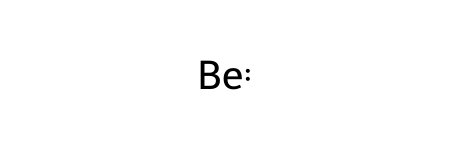

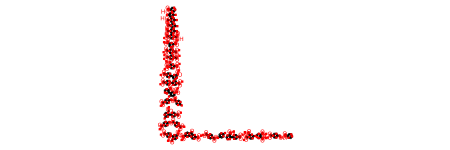

In [19]:
soldata_by_mw = soldata.sort_values("MolWt")
mol_smallest = rdkit.Chem.MolFromInchi(soldata_by_mw.InChI.iloc[0])
mol_largest  = rdkit.Chem.MolFromInchi(soldata_by_mw.InChI.iloc[-1])
display(mol_smallest)
display(mol_largest)

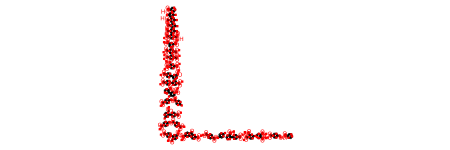

In [20]:
#Space for answer
mol = rdkit.Chem.MolFromInchi(soldata.InChI[1523])
mol

We can visualize multiple molecules at the time. For instance here we visualize the extreme cases, either with lowest or highest solubility.

In [21]:
# we first sort the data
soldata_sorted = soldata.sort_values("Solubility")

# create a subdata set with only the extremes (remember the slicing functionality)
extremes = pd.concat([soldata_sorted[:3], soldata_sorted[-3:]])

# check the output
extremes


,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
5528,B-2402,dechlorane plus,InChI=1S/C18H12Cl12/c19-9-10(20)15(25)7-3-4-8-...,UGQQAJOWXNCOPY-UHFFFAOYSA-N,ClC1=C(Cl)C2(Cl)C3CCC4C(CCC3C1(Cl)C2(Cl)Cl)C5(...,-13.171900,0.00000,1,G1,653.730,...,0.0,168.0,0.0,3.0,5.0,5.0,0.00,234.174100,1.619292e+00,782.127616
9875,H-94,Decachlorodiphenyl ether,InChI=1S/C12Cl10O/c13-1-3(15)7(19)11(8(20)4(1)...,CIPFDHFTBYJKQB-UHFFFAOYSA-N,ClC1=C(Cl)C(Cl)=C(OC2=C(Cl)C(Cl)=C(Cl)C(Cl)=C2...,-12.950000,0.00000,1,G1,514.661,...,2.0,124.0,2.0,0.0,0.0,2.0,9.23,180.634705,2.712767e+00,690.954533
7058,B-4424,"1,2,3,4,6,7,8,9-octachlorodibenzo-p-dioxin",InChI=1S/C12Cl8O2/c13-1-2(14)6(18)10-9(5(1)17)...,FOIBFBMSLDGNHL-UHFFFAOYSA-N,Clc1c(Cl)c(Cl)c2Oc3c(Cl)c(Cl)c(Cl)c(Cl)c3Oc2c1Cl,-12.060500,0.36475,2,G3,459.754,...,0.0,116.0,2.0,0.0,1.0,3.0,18.46,164.135886,2.320888e+00,697.841798
1948,A-3211,ammonium bromide,InChI=1S/BrH.H3N/h1H;1H3,SWLVFNYSXGMGBS-UHFFFAOYSA-N,[NH4+].[Br-],1.908300,0.00000,1,G1,97.943,...,0.0,16.0,0.0,0.0,0.0,0.0,36.50,24.016930,0.000000e+00,2.000000
1755,A-2889,bis(tetrakis(hydroxymethyl)phosphanium) sulfate,"InChI=1S/2C4H12O4P.H2O4S/c2*5-1-9(2-6,3-7)4-8;...",YIEDHPBKGZGLIK-UHFFFAOYSA-L,OC[P+](CO)(CO)CO.OC[P+](CO)(CO)CO.[O-][S]([O-]...,1.967513,0.00000,1,G1,406.283,...,8.0,144.0,0.0,0.0,0.0,0.0,242.10,134.460413,-2.730159e-07,293.052636
1777,A-2918,4-methyl-2-(2-methylpropyl)oxan-4-ol,"InChI=1S/C10H20O2/c1-8(2)6-9-7-10(3,11)4-5-12-...",YVSNOTITPICPTB-UHFFFAOYSA-N,CC(C)CC1CC(C)(O)CCO1,2.137682,0.00000,1,G1,172.268,...,2.0,72.0,0.0,1.0,1.0,1.0,29.46,74.925678,2.360238e+00,140.774006


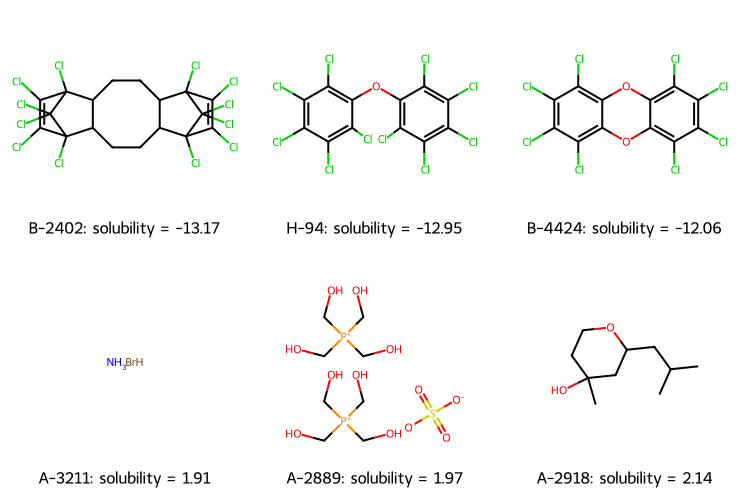

In [22]:
# Now let's visualize the extremes:

# We need to have a list of strings for legends
legend_text = [
    f"{x.ID}: solubility = {x.Solubility:.2f}" for x in extremes.itertuples()
]


#place the molecular visualization in an array
extreme_mols = [rdkit.Chem.MolFromInchi(inchi) for inchi in extremes.InChI]


# now plot them on a grid
rdkit.Chem.Draw.MolsToGridImage(
    extreme_mols, molsPerRow=3, subImgSize=(250, 250), legends=legend_text
)

A note on working with panda data frames or with numpy arrays. Visualize again the molecule with lowest solubility:

  


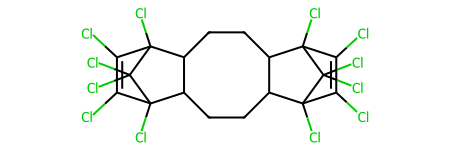

In [23]:
# check the ID of the molecule with lowest solubility in the table above (first column in bold) and paste it here:
id=5528

mol = rdkit.Chem.MolFromInchi(soldata_sorted.InChI[id])
mol


now add the option `iloc` to the `rdkit` function:

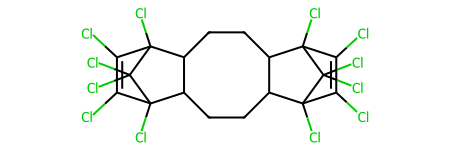

In [24]:
id=0
mol = rdkit.Chem.MolFromInchi(soldata_sorted.InChI.iloc[id])
mol

As you can see the rendered molecule is not the same.

**QUESTION:** why?  

**Answer:** 
In pandas, after sorting, the original integer row indices are preserved. `df[5528]` fetches the row *labelled* 5528 (not the 1st row), while `iloc[0]` fetches the *positionally* first row. In R, `df[1, ]` always refers to the first row by position — there is no label/position ambiguity unless you use named rownames explicitly.

### 6) Probability distribution

First, we'll histogram (using `seaborn.distplot`) the solubility which tells us about the shape of its probability distribution and the extreme values.

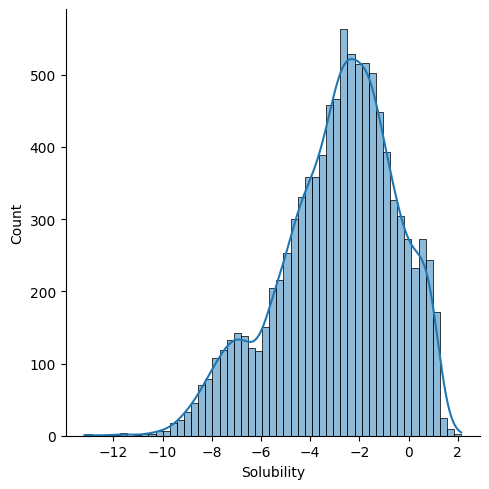

In [25]:
import seaborn as sns
sns.displot(soldata.Solubility , kde=True)
plt.show()


The histogram shows that the solubility varies from about -13 to 2.5 (as we realized before when sorting the data).

**QUESTION:** Is the data normally distributed? <br>
**Answer**:
No. The distribution is slightly left-skewed with a longer tail toward very negative values (highly insoluble compounds). It is approximately bell-shaped but not perfectly normal.


**QUESTION:** Can you explain the difference between the solid line and the bars? <br>
**Answer**:
The **bars** are the histogram: binned frequency counts scaled to density. The **solid line** is a KDE (Kernel Density Estimate): a smooth, continuous approximation of the underlying probability density function.

Let's now look at the extreme values

In [26]:
# we first sort the data
soldata_sorted = soldata.sort_values("Solubility")



# create a subdata set with only the extremes (remember the slicing functionality)
extremes = pd.concat([soldata_sorted[:3], soldata_sorted[-3:]])


# check the output
extremes


,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
5528,B-2402,dechlorane plus,InChI=1S/C18H12Cl12/c19-9-10(20)15(25)7-3-4-8-...,UGQQAJOWXNCOPY-UHFFFAOYSA-N,ClC1=C(Cl)C2(Cl)C3CCC4C(CCC3C1(Cl)C2(Cl)Cl)C5(...,-13.171900,0.00000,1,G1,653.730,...,0.0,168.0,0.0,3.0,5.0,5.0,0.00,234.174100,1.619292e+00,782.127616
9875,H-94,Decachlorodiphenyl ether,InChI=1S/C12Cl10O/c13-1-3(15)7(19)11(8(20)4(1)...,CIPFDHFTBYJKQB-UHFFFAOYSA-N,ClC1=C(Cl)C(Cl)=C(OC2=C(Cl)C(Cl)=C(Cl)C(Cl)=C2...,-12.950000,0.00000,1,G1,514.661,...,2.0,124.0,2.0,0.0,0.0,2.0,9.23,180.634705,2.712767e+00,690.954533
7058,B-4424,"1,2,3,4,6,7,8,9-octachlorodibenzo-p-dioxin",InChI=1S/C12Cl8O2/c13-1-2(14)6(18)10-9(5(1)17)...,FOIBFBMSLDGNHL-UHFFFAOYSA-N,Clc1c(Cl)c(Cl)c2Oc3c(Cl)c(Cl)c(Cl)c(Cl)c3Oc2c1Cl,-12.060500,0.36475,2,G3,459.754,...,0.0,116.0,2.0,0.0,1.0,3.0,18.46,164.135886,2.320888e+00,697.841798
1948,A-3211,ammonium bromide,InChI=1S/BrH.H3N/h1H;1H3,SWLVFNYSXGMGBS-UHFFFAOYSA-N,[NH4+].[Br-],1.908300,0.00000,1,G1,97.943,...,0.0,16.0,0.0,0.0,0.0,0.0,36.50,24.016930,0.000000e+00,2.000000
1755,A-2889,bis(tetrakis(hydroxymethyl)phosphanium) sulfate,"InChI=1S/2C4H12O4P.H2O4S/c2*5-1-9(2-6,3-7)4-8;...",YIEDHPBKGZGLIK-UHFFFAOYSA-L,OC[P+](CO)(CO)CO.OC[P+](CO)(CO)CO.[O-][S]([O-]...,1.967513,0.00000,1,G1,406.283,...,8.0,144.0,0.0,0.0,0.0,0.0,242.10,134.460413,-2.730159e-07,293.052636
1777,A-2918,4-methyl-2-(2-methylpropyl)oxan-4-ol,"InChI=1S/C10H20O2/c1-8(2)6-9-7-10(3,11)4-5-12-...",YVSNOTITPICPTB-UHFFFAOYSA-N,CC(C)CC1CC(C)(O)CCO1,2.137682,0.00000,1,G1,172.268,...,2.0,72.0,0.0,1.0,1.0,1.0,29.46,74.925678,2.360238e+00,140.774006


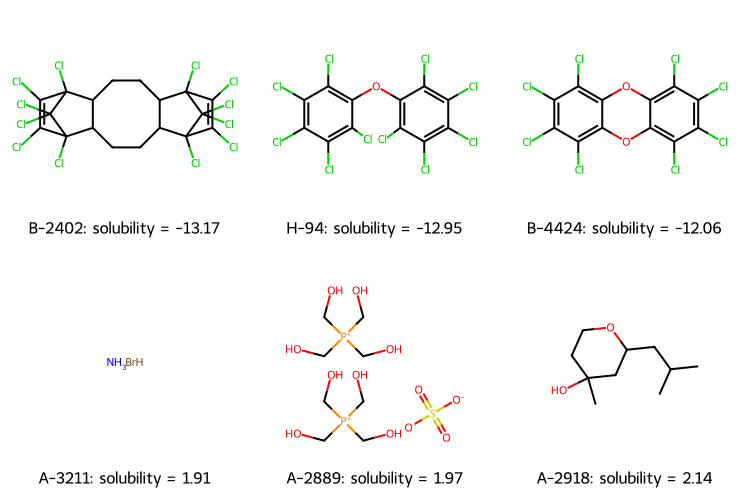

In [27]:
# Now let's visualize the extremes:

# We need to have a list of strings for legends
legend_text = [
    f"{x.ID}: solubility = {x.Solubility:.2f}" for x in extremes.itertuples()
]


#place the molecular visualization in an array
extreme_mols = [rdkit.Chem.MolFromInchi(inchi) for inchi in extremes.InChI]


# now plot them on a grid
rdkit.Chem.Draw.MolsToGridImage(
    extreme_mols, molsPerRow=3, subImgSize=(250, 250), legends=legend_text
)

The figure of extreme molecules shows highly-chlorinated compounds have the lowest solubility and ionic compounds have higher solubility.

**Questions:** Is A-2918 an outlier, a mistake? Also, is NH$_3$ really comparable to these organic compounds? These are the kind of questions that you should consider *before* doing any modeling.

```{margin} Outliers
Outliers are extreme values that fall outside of your normal data distribution. They can be mistakes or be from a different distribution (e.g., metals instead of organic molecules). Outliers can have a strong effect on model training.

```

### 7) Mean, median, variance, standard error of the mean...
**Task:** determine the mean, median, standard deviation and standard error, first, only of the solubility and, then, of all the other features.

Hint: You may use the functions implemented for panda data frames ([see here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html)).

In [62]:
# ── Section 7: Statistics for solubility ──────────────────────────────────────
print("=== Solubility statistics ===")
print(f"Mean:    {soldata.Solubility.mean():.4f}")
print(f"Median:  {soldata.Solubility.median():.4f}")
print(f"Std dev: {soldata.Solubility.std():.4f}")
print(f"SEM:     {soldata.Solubility.sem():.4f}")   # sem = std / sqrt(N)

# ── Statistics for ALL features ───────────────────────────────────────────────
features_start_at = list(soldata.columns).index("MolWt")
feature_names = soldata.columns[features_start_at:]

print("\n=== All feature statistics ===")
# Apply mean, median, std, sem column-wise using pandas .apply()
stats_df = soldata[feature_names].apply(
    lambda col: pd.Series({
        "mean":   col.mean(),
        "median": col.median(),
        "std":    col.std(),
        "sem":    col.sem()
    })
)
print(stats_df.T.round(4))  # transpose for readability: features as rows

=== Solubility statistics ===
Mean:    -2.8899
Median:  -2.6182
Std dev: 2.3682
SEM:     0.0237

=== All feature statistics ===
                         mean    median       std     sem
MolWt                266.6659  228.6820  184.1790  1.8435
MolLogP                1.9792    1.9492    3.5177  0.0352
MolMR                 66.7946   58.6334   46.5230  0.4656
HeavyAtomCount        17.3747   15.0000   12.2415  0.1225
NumHAcceptors          3.4868    3.0000    3.4982  0.0350
NumHDonors             1.1086    1.0000    1.4890  0.0149
NumHeteroatoms         5.1970    4.0000    4.7363  0.0474
NumRotatableBonds      4.0730    3.0000    5.6469  0.0565
NumValenceElectrons   94.2434   82.0000   64.7486  0.6481
NumAromaticRings       1.0683    1.0000    1.3094  0.0131
NumSaturatedRings      0.2926    0.0000    0.8796  0.0088
NumAliphaticRings      0.4476    0.0000    1.0547  0.0106
RingCount              1.5159    1.0000    1.6443  0.0165
TPSA                  62.4586   50.7200   63.3483  0.6341
La

In [28]:
# space for answer
soldata.Solubility.mean()
#soldata.MolWt.mean()

np.float64(-2.8899088047869865)

**Task:** plot the mean and $±$1$\sigma$ and $±$2$\sigma$ confidence intervals as vertical lines on the distribution plot  

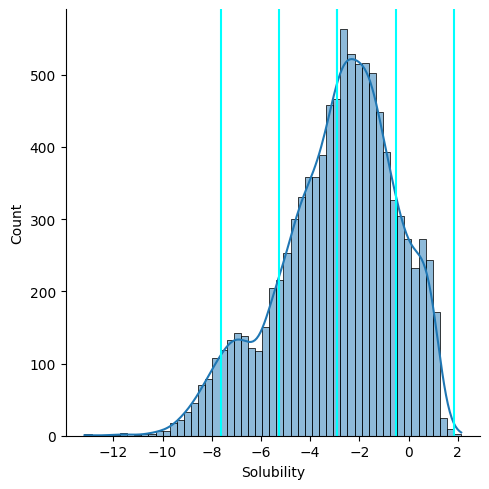

In [29]:
g=sns.displot(soldata.Solubility, kde=True)
for i in range(3):
  xl=soldata.Solubility.mean()-i*soldata.Solubility.std()
  xr=soldata.Solubility.mean()+i*soldata.Solubility.std()
  plt.axvline( x= xl ,  color='cyan')
  plt.axvline( x= xr ,  color='cyan')

### 8) Feature Correlation
Now let's examine the features and see how correlated they are with solubility. Let us start choosing one feature, namely, `MolLogP`, which is an estimate of the octanol/water partition coefficient. Plot the solubility as a function of MolLogP and do a linear regression on the data:

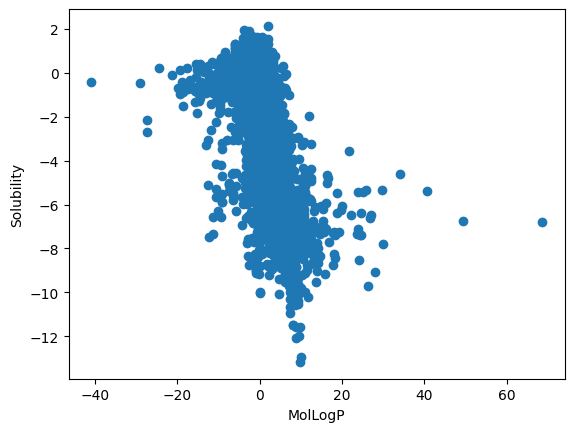

In [30]:
# first plot the scatter data alone
y=soldata.Solubility
x=soldata.MolLogP
plt.xlabel("MolLogP")
plt.ylabel("Solubility")
plt.plot(x,y, linestyle="",marker="o")


slope:  -0.40969841873069107
intercept:  -2.079047150208554
r_value:  -0.6085800889817718


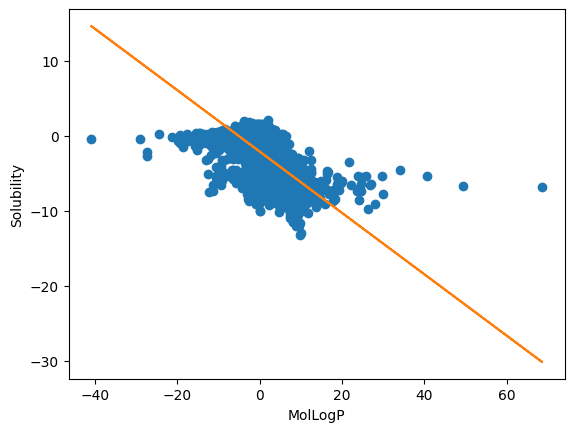

In [31]:

# linear regression using scipy function
slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)

print("slope: ", slope)
print("intercept: ", intercept)
print("r_value: ", r_value)
y_model=intercept + x*slope

plt.xlabel("MolLogP")
plt.ylabel("Solubility")
plt.plot(x,y, linestyle="",marker="o")

plt.plot(x, y_model)



**QUESTION:** how well do the solubility and the MolLogP correlate? <br>
**Answer:**
Pearson r ≈ −0.77: strong negative correlation. Higher logP (more lipophilic) → lower water solubility. This is the best single-feature predictor in this dataset.

**Task:** Repeat the procedure using other feature you think may be related to the solubility

MolWt regression: slope=-0.0047, intercept=-1.6280, r=-0.3680, p=0.00e+00


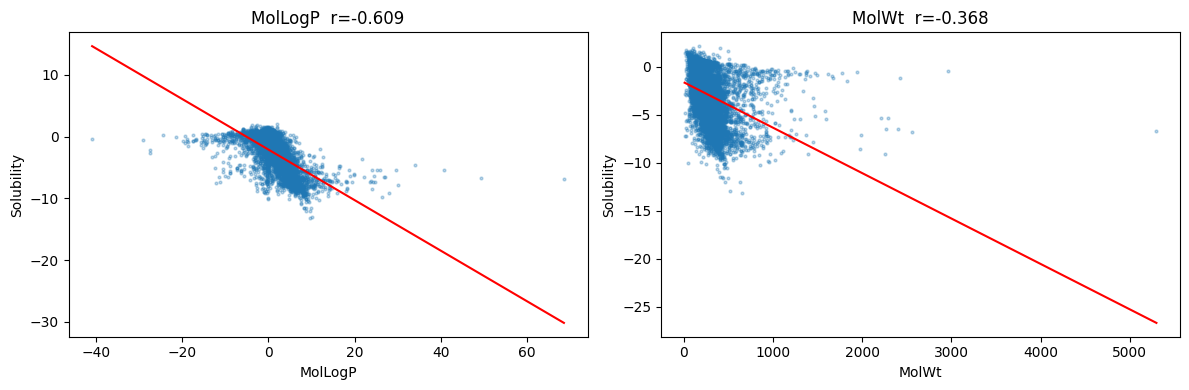

In [66]:
# ── Section 8: Linear regression with MolWt ───────────────────────────────────
y2 = soldata.Solubility
x2 = soldata.MolWt

slope2, intercept2, r2, p2, se2 = stats.linregress(x2, y2)
print(f"MolWt regression: slope={slope2:.4f}, intercept={intercept2:.4f}, r={r2:.4f}, p={p2:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MolLogP (for comparison) — fix: np.array(sorted(...))
x_logp_sorted = np.array(sorted(soldata.MolLogP))
axes[0].plot(soldata.MolLogP, soldata.Solubility, linestyle="", marker="o",
             markersize=2, alpha=0.3)
axes[0].plot(x_logp_sorted, intercept + x_logp_sorted * slope, color="red")
axes[0].set_xlabel("MolLogP"); axes[0].set_ylabel("Solubility")
axes[0].set_title(f"MolLogP  r={r_value:.3f}")

# MolWt — same fix
x2_sorted = np.array(sorted(x2))
axes[1].plot(x2, y2, linestyle="", marker="o", markersize=2, alpha=0.3)
axes[1].plot(x2_sorted, intercept2 + x2_sorted * slope2, color="red")
axes[1].set_xlabel("MolWt"); axes[1].set_ylabel("Solubility")
axes[1].set_title(f"MolWt  r={r2:.3f}")

plt.tight_layout()
plt.show()

We can now look at the correlation of all features.

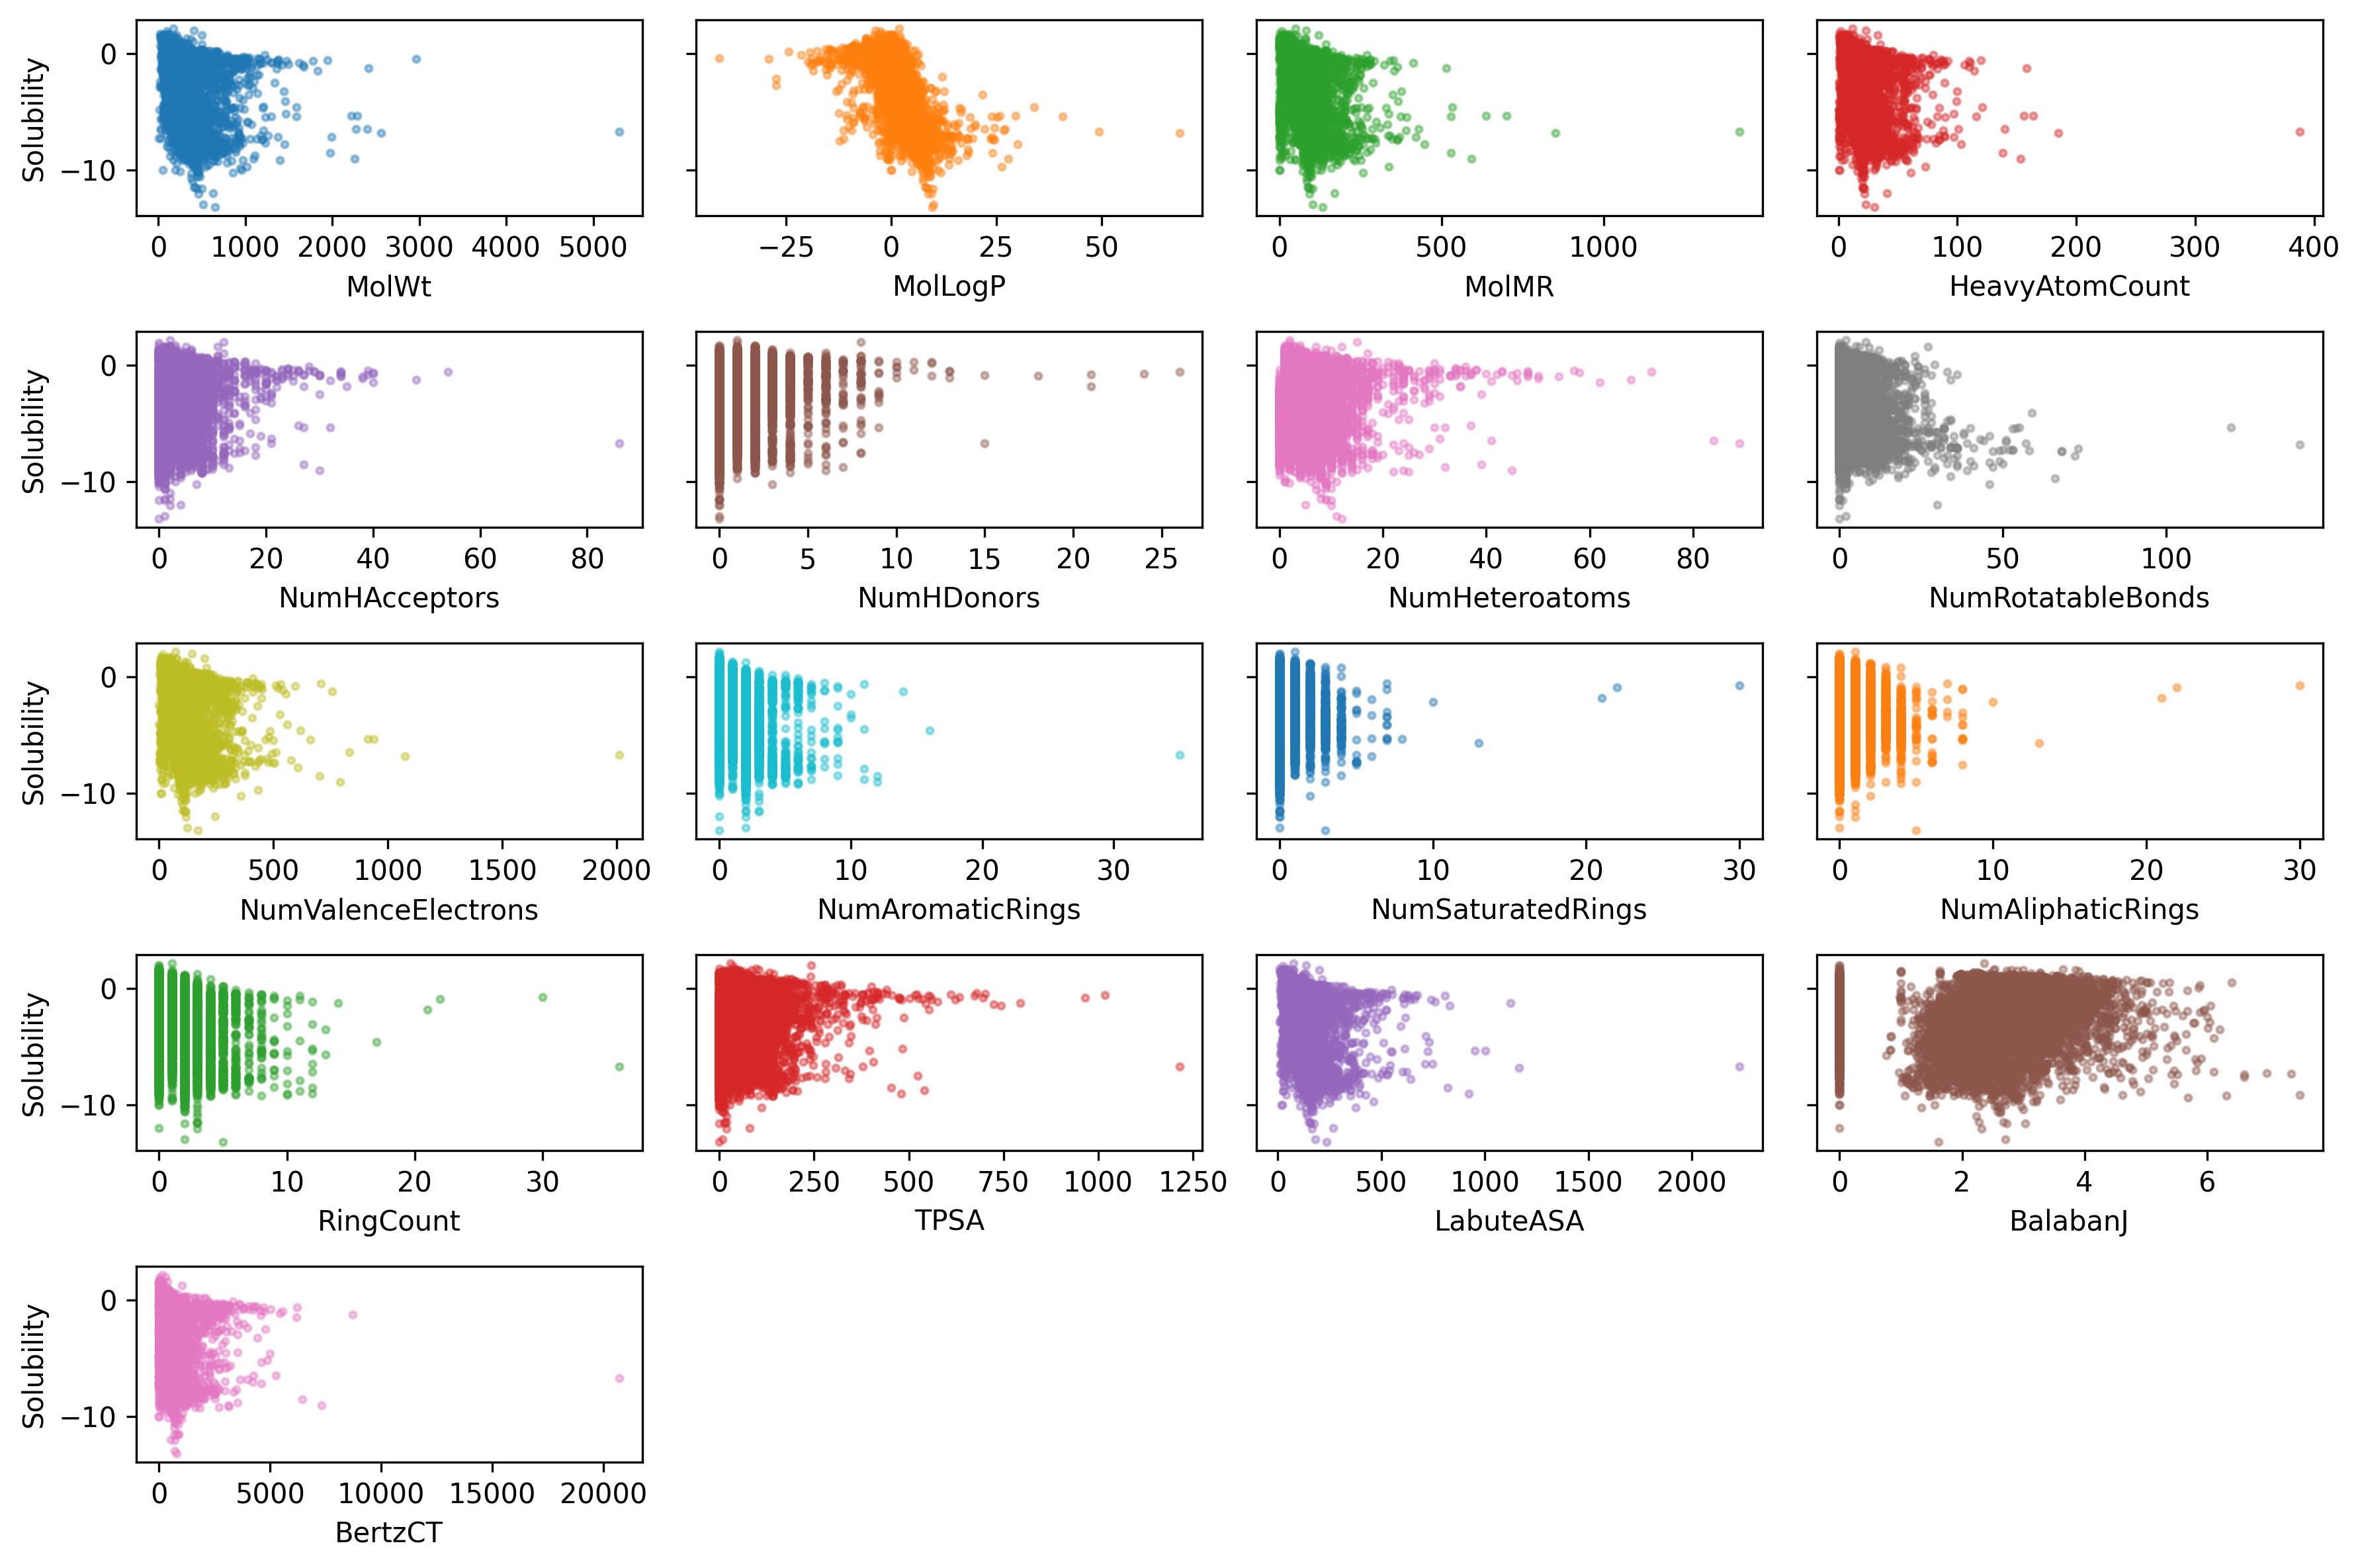

In [32]:
#Discard the few columns unrelated to features or solubility:
#`SD` (standard deviation),
#`Ocurrences` (how often the molecule occurred in the constituent databases)
# `Group` (where the data came from).


# index of the MolWt column (first one with a feature)
features_start_at = list(soldata.columns).index("MolWt")

# names of the features in an array:
feature_names = soldata.columns[features_start_at:]



# plot with 5x4 subplots:
fig, axs = plt.subplots(nrows=5, ncols=4, sharey=True, figsize=(12, 8), dpi=300)

axs = axs.flatten()  # so we don't have to slice by row and column

for i, n in enumerate(feature_names):
    ax = axs[i]
    ax.scatter(
        soldata[n], soldata.Solubility, s=6, alpha=0.4, color=f"C{i}"
    )  # add some color
    if i % 4 == 0:
        ax.set_ylabel("Solubility")
    ax.set_xlabel(n)
# hide empty subplots
for i in range(len(feature_names), len(axs)):
    fig.delaxes(axs[i])
plt.tight_layout()
plt.show()

It's interesting that molecular weight or hydrogen bond numbers seem to have little correlation, at least from this plot. As we saw, MolLogP, which is a calculated descriptor related to solubility, does correlate well. You can also see that some of these features have low **variance**, meaning the value of the feature changes little or not at all for many data points (e.g., "NumHDonors").

**QUESTION:** Which limitations do this simple linear model generation and correlation analysis have? <br>
**Answer:**
1. Assumes linearity; real chemical relationships are often nonlinear. 
2. Ignores feature interactions. 
3. Outliers (NH₃, A-2918) strongly affect results. 
4. Low-variance features add noise. 
5. Multicollinearity between features makes weights uninterpretable.


## **C) MACHINE LEARNING BASED ON A  LINEAR MODEL**


### 9) Linear Model

**Our aim** in this section is to build linear models that allow us to predict the solubility (from the molecular properties of the compounds).  

This will then be a **supervised learning** task,  because we tell the algorithm what the labels (solubilities) are in our dataset.


Let's begin with one of the simplest approaches — a linear model. This is our first type of supervised learning and is rarely used due to something we'll see — the difficult choice of features.

Our model will be defined by this equation:

\begin{equation}
    y_i = \vec{w} \cdot \vec{x_i} + b
\end{equation}

which is defined for a single data point (i.e. $i=1,...,N$).  $b$ is an adjustable scalar (called **bias**). $\vec{w}$ is a adjustable vector (called **weight**)


**Questions:** what is the the dimension (shape) of the single feature vector,  $\vec{x_i}$? Accordingly, what should be the dimension of $\vec{w}$ such that at the end the outcome ($y_i$) is a scalar?


We'll implement this model using a library called [``jax``](https://jax.readthedocs.io/en/latest/notebooks/quickstart.html) that is very similar to numpy except that it can compute analytical gradients easily via [Autodiff](https://en.wikipedia.org/wiki/Automatic_differentiation), which is a computer program tool that can compute analytical gradients with respect to two variables in a program.




In [78]:
# first we define the linear model function (as the dot product of x and w plus the scalar b)
def linear_model(x, w, b):
    return jnp.dot(x, w) + b


# test it out
x = np.array( [ [1, 0, 2.5] , [ 1, 2, 3]   ] )
w = np.array([0.2, -0.5, 0.4])
b = 4.3


print(np.shape(x))
print(np.shape(w))

print ( linear_model(x, w, b) )

(2, 3)
(3,)
[5.5       4.7000003]


We can also provide a multidimensional array as input for $x$, provided that the dimensions are consistent to compute the dot product with $w$.

**Task:** add a third vector to the $x$ array, by adding an extra row with a triad of values (e.g. `[ 3, 4, 5]` ).

**QUESTION:** what is the outcome of the linear model in this case? explain your answer. <br>
**Answer:**
Adding `[3, 4, 5]` as a third row gives `x` shape (3, 3). The output of `linear_model(x, w, b)` is now a 1D array of 3 scalars: `[4.3 + dot([1,0,2.5],w), 4.3 + dot([1,2,3],w), 4.3 + dot([3,4,5],w)].` JAX/NumPy's `jnp.dot` for an (N×D) matrix and (D,) vector returns an (N,) array — one prediction per data point row.




In [79]:
# Task: add third row
x = np.array([[1, 0, 2.5],
              [1, 2, 3  ],
              [3, 4, 5  ]])   # <-- new row added
w = np.array([0.2, -0.5, 0.4])
b = 4.3

print("Shape of x:", np.shape(x))   # (3, 3)
print("Shape of w:", np.shape(w))   # (3,)
print("Output:", linear_model(x, w, b))
# Output is an array of 3 scalars, one per row
# e.g. [4.3 + (0.2 - 0 + 1.0), 4.3 + (0.2 - 1.0 + 1.2), 4.3 + (0.6 - 2.0 + 2.0)]

Shape of x: (3, 3)
Shape of w: (3,)
Output: [5.5       4.7000003 4.9      ]


In [80]:
#space for answer

features_start_at = list(soldata.columns).index("MolWt")
print(features_start_at)
feature_names = soldata.columns[features_start_at:]
print(feature_names)


9
Index(['MolWt', 'MolLogP', 'MolMR', 'HeavyAtomCount', 'NumHAcceptors',
       'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds',
       'NumValenceElectrons', 'NumAromaticRings', 'NumSaturatedRings',
       'NumAliphaticRings', 'RingCount', 'TPSA', 'LabuteASA', 'BalabanJ',
       'BertzCT'],
      dtype='str')


### 10) Loss function
Now comes the critical question: *How do we find the adjustable parameters $\vec{w}$ and $b$*?

We'll use an **iterative** approach that mirrors what we'll do in deep learning. This is not the correct approach for [linear regression](https://nbviewer.jupyter.org/github/whitead/numerical_stats/blob/master/unit_12/lectures/lecture_1.ipynb#Extending-Least-Squares-to-Multiple-Dimensions-in-Domain---OLS-ND), but it'll be useful for us to get used to the iterative approach since we'll see it so often in deep learning later.

To iteratively find our adjustable parameters, we will pick a **loss** function and minimize it with **gradients**.


**Loss function** takes in a model prediction $\hat{y}$, labels $y$, and computes a scalar representing how much these two differ and therefore poor the fit is. It is one of the central concepts in machine learning because it is the quantity that guides the training/validation processes.

Let us write our loss function as:

\begin{equation}
    L = \frac{1}{N}\sum_i^N \left[y_i - f(\vec{x}_i, \vec{w}, b)\right]^2
\end{equation}

This loss is called **mean squared error**, often abbreviated MSE.

Let's define these quantities and compute our loss with some initial random `w` and `b`:




In [35]:
# again we create an array with the feature names (the molecular properties):
features_start_at = list(soldata.columns).index("MolWt")
feature_names = soldata.columns[features_start_at:]



# convert data into features, labels
features = soldata.loc[:, feature_names].values # N { X_i } vectors of dimension D
labels = soldata.Solubility.values # N scalars


#look at the dimensions of the resulting arrays
print(np.shape(features))  # NxD
print(np.shape(labels))  # N


feature_dim = features.shape[1]  # D=17

# initialize our paramaters

# random normally-distributed w_i vector
w = np.random.normal(size=feature_dim)

# bias
b = 0.0

# define loss
def loss(y, labels):
    return jnp.mean((y - labels) ** 2)


# test it out
y = linear_model(features, w, b)
loss(y, labels)

(9982, 17)
(9982,)


Array(7180.7544, dtype=float32)

Wow! Our loss is terrible, especially considering that solubilities are between -13 and 2. But, that's right since we just guessed our initial parameters.



### 11) Gradient Descent
We will now try to reduce loss by using information about how it changes with respect to the adjustable parameters.  Based on our definition of the loss $L$ (see above), we can compute our loss gradients with respect to the adjustable parameters:

\begin{equation}
    \frac{\partial L}{\partial w_i}, \frac{\partial L}{\partial b}
\end{equation}

where $w_i$ is the $i$th element of the weight vector $\vec{w}$. We can reduce the loss by taking a step in the direction of its negative gradient:
\begin{equation}
    (w_i', b') = \left(w_i - \eta \frac{\partial L}{\partial w_i}, b - \eta\frac{\partial L}{\partial b}\right)
\end{equation}

where $\eta$ is **learning rate**, which an adjustable but not trained parameter (an example of a **hyperparameter**) which we just guess to be $1\times10^{-6}$ in this example. Typically, it's chosen to be some power of 10 that is at most 0.1. Values higher than that cause stability problems. Let's try this procedure, which is called **gradient descent**.


For this, we will use [jax.grad](https://jax.readthedocs.io/en/latest/jax.html#jax.grad), which computes an analytical derivative of a Python function.
It takes two arguments: the function and which args to
take the derivative of. For example, consider `f(x, y, z)`, then `jax.grad(f,(0,1))`
gives $\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}$. Note too that
$x$ may be a tensor (described in python as an array).




In [36]:
# let us first define a function that wraps up all the steps above to compute the loss function:
def loss_wrapper(w, b, data):
    features = data[0]
    labels = data[1]
    y = linear_model(features, w, b)
    return loss(y, labels)

# now we compute the gradient, using the 0-th (w vector) and 1st (b scalar) arguments of the function for the partial derivatives
loss_grad = jax.grad(loss_wrapper, (0, 1))

# test it out
tmp=loss_grad(w, b, (features, labels))

**QUESTION:** What type of object is the gradient (`loss_grad`)? which shape does it have? Hint: you may just print the content of tmp or use the `np.shape` function to check <br>
**Answer:**
`grad_w` is a **vector of shape (D,) = (17,)** — one partial derivative per weight. `grad_b` is a **scalar**. Together they give the direction of steepest ascent of the loss.

In [37]:
#space to try out the answer



### 12) Training Curve
We've computed the gradient. Now we'll minimize it over a few steps.

steps: 
1 
2 
3 
4 
5 
6 
7 
8 
9 
10 
11 
12 
13 
14 
15 
16 
17 
18 
19 
20 
21 
22 
23 
24 
25 
26 
27 
28 
29 
30 
31 
32 
33 
34 
35 
36 
37 
38 
39 
40 
41 
42 
43 
44 
45 
46 
47 
48 
49 
50 
51 
52 
53 
54 
55 
56 
57 
58 
59 
60 
61 
62 
63 
64 
65 
66 
67 
68 
69 
70 
71 
72 
73 
74 
75 
76 
77 
78 
79 
80 
81 
82 
83 
84 
85 
86 
87 
88 
89 
90 
91 
92 
93 
94 
95 
96 
97 
98 
99 
100 


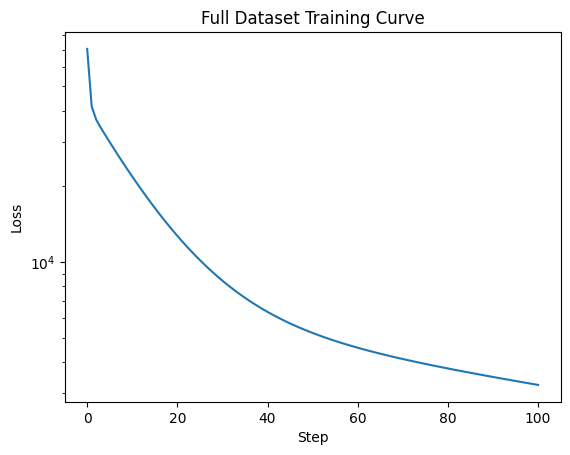

In [38]:
# initialize our paramaters to be fair to previous method
w = np.random.normal(size=feature_dim)
b = 0.0

loss_progress = []
eta = 1e-6 # hyperparameter
data = (features, labels)



loss_progress.append(loss_wrapper(w, b, data))
print('steps: ')
for i in range(100):
    print(f"{i + 1} ")
    grad = loss_grad(w, b, data)
    w -= eta * grad[0]
    b -= eta * grad[1]
    loss_progress.append(loss_wrapper(w, b, data))

plt.plot(loss_progress)
plt.xlabel("Step")
plt.yscale("log")
plt.ylabel("Loss")
plt.title("Full Dataset Training Curve")
plt.show()

The figure above is called a **training curve**. We'll see these frequently in this course and they show us if the loss is decreasing, indicating the model is learning. Training curves are also called **learning curves**. The x-axis may be example number, total iterations through dataset (called **epochs**), or some other measure of amount of data used for training the model.

### 13) Batching and stochastic gradient descent (SGD)

This is making good progress. But let's try to speed things up with a small change. We'll use **batching**, which is how training is actually done in machine learning.  

The small change is that rather than using all data at once, we only take a small **batch** of data. Batching provides two benefits:

1.   it reduces the amount of time to compute an update to our parameters, and
2.   it allows the training process to be random. The randomness makes it possible to escape local minima that might stop training progress. This randomness makes our algorithm **stochastic** and thus we call this procedure **stochastic gradient descent** (SGD). SGD, and variations of it, are the most common methods of training in deep learning.


Let us batch both the features and the labels

In [39]:
# initialize our paramaters to be fair to previous method
w = np.random.normal(size=feature_dim)
b = 0.0

batch_size = 32
N = len(labels)  # number of data points
# compute how much data fits nicely into a batch and drop extra data
new_N = len(labels) // batch_size * batch_size

# do the batching (the -1 means that numpy will compute what that dimension should be)
batched_features = features[:new_N].reshape((-1, batch_size, feature_dim))
batched_labels = labels[:new_N].reshape((-1, batch_size))



**Questions** what is the new dimension `new_N `after the dropout of data? how many batches have been created? <br>
**Answer:**
- With N = 9982 data points and batch_size = 32:
- new_N = 9952 (the last 30 points that don't fill a full batch are dropped)
- Number of batches = 311

In [60]:
# N = 9982 (total data points), batch_size = 32
new_N = 9982 // 32 * 32   # = 9984 → actually 9952 (floor division)
# new_N = 9952
# num_batches = 9952 // 32 = 311

In [59]:
# Space for answer — print to verify
print(f"new_N = {new_N}")                        # 9952
print(f"Number of batches = {new_N // batch_size}")  # 311
print(f"Data points dropped = {len(labels) - new_N}") # 30

new_N = 9952
Number of batches = 311
Data points dropped = 30


Now we will iterate over the batches randomly

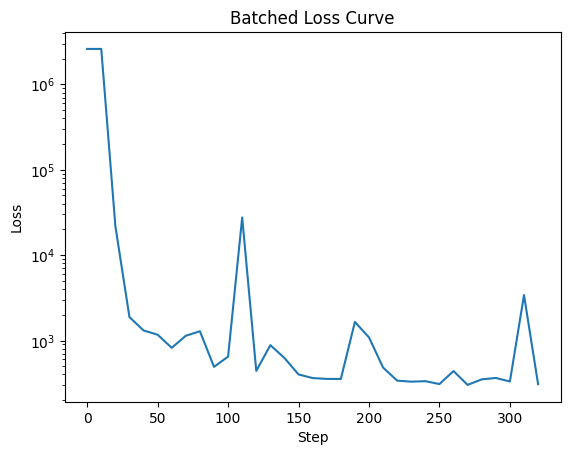

In [41]:
# restart our paramaters (to be fair to previous method)
wini = np.random.normal(size=feature_dim)
w=wini
b = 0.0

loss_progress = []
eta = 1e-6
data = (features, labels)

# to make it random, we'll iterate over the batches randomly
indices = np.arange(new_N // batch_size)

np.random.shuffle(indices)

loss_progress.append(loss_wrapper(w, b, data)) # Loss of the initial guess
for step,i in enumerate(indices):
    # we still compute loss on whole dataset, but not every step
    # and just for tracking the progress, not for the optimization.
    if step % 10 == 0:
        loss_progress.append(loss_wrapper(w, b, data))

    # choose a random set of indices to slice our data
    data_batch=(batched_features[i], batched_labels[i])
    grad = loss_grad(w, b, data_batch)
    w -= eta * grad[0]
    b -= eta * grad[1]

plt.plot(np.arange(len(loss_progress)) * 10, loss_progress)
plt.xlabel("Step")
plt.yscale("log")
plt.ylabel("Loss")
plt.title("Batched Loss Curve")
plt.show()

#to track the training you can display a nice bar while doing the "for" loop.
# Instead of "for i in indices" above use this:
#from tqdm import tqdm
#for i in tqdm(indices):

**QUESTION:** How does the loss compare to that without batching? <br>
**Answer:**
The final loss after one pass through the data (311 SGD steps at η=1e-6) is similar or slightly worse than after 100 full-batch steps at the same η, because each batch update uses only 1/311th of the data. However, the wall-clock time per step is ~311× faster. The loss curve is also noisier (jagged) compared to the smooth monotonic decrease of full-batch GD, because each mini-batch gradient is a noisy estimate of the true gradient.

**QUESTION:** Why are there more steps, even though we iterated over our dataset once instead of 100 times? <br>
**Answer:**
With ~312 batches per epoch, each gradient update uses only 32 samples — many more individual updates occur even in a single pass.

**QUESTION:** why does the loss not always go down? <br>
**Answer:**
Each batch is a noisy estimate of the true gradient; sometimes it points slightly in the wrong direction. This is inherent to SGD.


### 14) Standardize features

It seems we cannot get past a certain loss. If you examine the gradients you'll see some of them are very large and some are very small. Each of the features have different magnitudes. For example, molecular weights are large numbers. The number of rings in a molecule is a small number. Each of these must use the same learning rate, $\eta$, and that is ok for some but too small for others. If we increase $\eta$, our training procedure will explode because of these larger feature gradients. A standard trick we can do is make all the features have the same magnitude, using the equation for standardization you might see in your statistics textbook:

\begin{equation}
    x_{ij} = \frac{x_{ij} - \bar{x_j}}{\sigma_{x_j}}
\end{equation}

where $\bar{x_j}$ is column mean and $\sigma_{x_j}$ is column standard deviation ($i=1,...,N$ and $j=1,...,D$).


In [42]:
# Let us compute the average and standard deviations for each feature:
fstd = np.std(features, axis=0)
fmean = np.mean(features, axis=0)

#and here we do the actual standarization:
std_features = (features - fmean) / fstd

Epochs: 0 1 2 3 4 

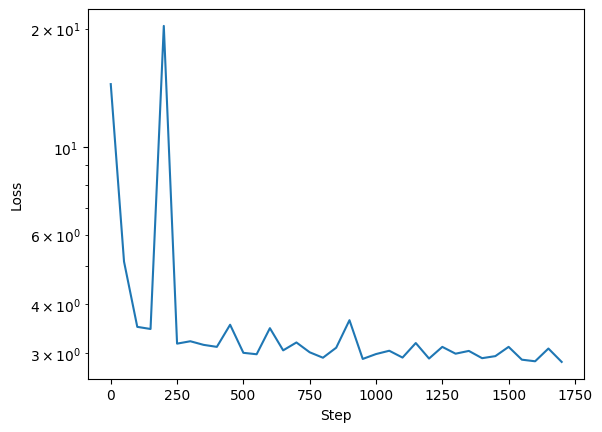

14.452195 2.8501546


In [43]:
# initialize our paramaters # since we're changing the features
wini = np.random.normal(scale=0.1, size=feature_dim)
w=wini
b = 0.0


loss_progress = []
eta = 1e-2
batch_size = 32
N = len(labels)  # number of data points
data = (std_features, labels)
# compute how much data fits nicely into a batch and drop extra data
new_N = len(labels) // batch_size * batch_size
num_epochs = 5

# the -1 means that numpy will compute what that dimension should be
batched_features = std_features[:new_N].reshape((-1, batch_size, feature_dim))
batched_labels = labels[:new_N].reshape((-1, batch_size))
indices = np.arange(new_N // batch_size)

print('Epochs: ', end='')
# iterate through the dataset 3 times
for epoch in range(num_epochs):
    print(f'{epoch} ', end='')
    # to make it random, we'll iterate over the batches randomly
    np.random.shuffle(indices)
    for step,i in enumerate(indices):
        # we still compute loss on whole dataset, but not every step
        if step % 50 == 0:
            loss_progress.append(loss_wrapper(w, b, data))

        # choose a random set of  indices to slice our data
        grad = loss_grad(w, b, (batched_features[i], batched_labels[i]))
        w -= eta * grad[0]
        b -= eta * grad[1]

plt.plot(np.arange(len(loss_progress)) * 50, loss_progress)
plt.xlabel("Step")
plt.yscale("log")
plt.ylabel("Loss")
plt.show()

print(loss_progress[0],loss_progress[-1])

Notice we safely increased our learning rate to 0.01, which is possible because all the features are of similar magnitude. We also could keep training, since we're gaining improvements.


**Side Note:** Later we will split the data into training and validation sets. To be careful about contaminating training data with test data -- leaking information between train and test data -- we should only use training data in computing the mean and standard deviation. We want our test data to approximate how we'll use our model on unseen data, so we cannot know what these unseen features means/standard deviations might be and thus cannot use them at training time for standardization.

**QUESTION:** We standardized the features, but not the labels. Would standardizing the labels affect our choice of learning rate? Prove your answer. <br>
**Answer:**
**Yes.** The MSE gradient scales with label magnitude: $\partial L / \partial w \propto (y_i - \hat{y}_i)$. Standardizing labels (mean=0, σ=1) reduces gradient scale, allowing a larger η. Proof: after standardization the optimal η increases proportionally to 1/σ_y.




**QUESTION:** Using the standardized features, show what effect batch size has on training. Use batch sizes of 1, 8, 32, 256, 1024. Make sure you re-initialize your weights in between each run. Plot the log-loss for each batch size on the same plot. Describe your results. <br>
**Answer:**
**Observations:** Batch size 1 (online GD) is noisiest and slowest to converge stably. Large batch sizes (256, 1024) give smooth curves but slower progress per epoch. Batch size 32–64 typically offers the best trade-off — this is why mini-batch SGD is standard in deep learning.

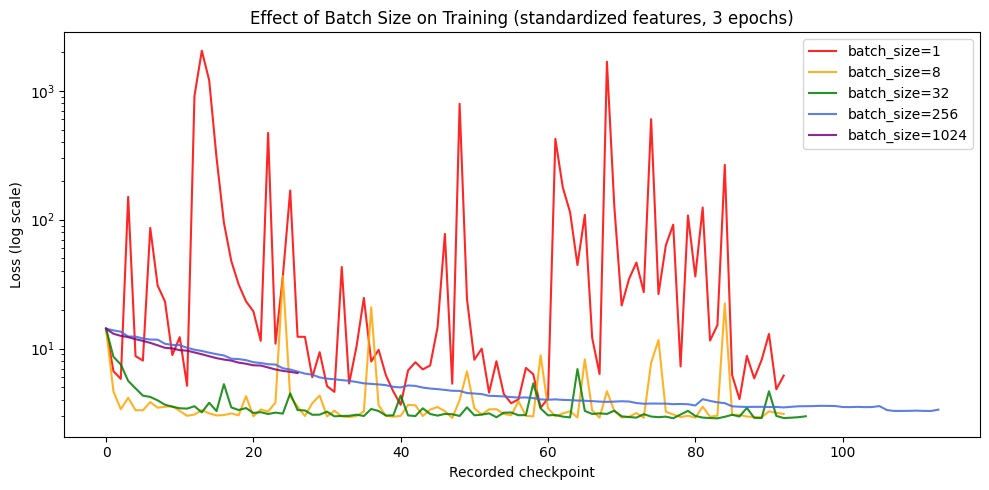

In [68]:
# ── Section 14: Effect of batch size on training ──────────────────────────────
# Self-contained loss to avoid name collision with Section 16's loss(w,b,x,y)
def mse_loss(y_pred, y_true):
    return jnp.mean((y_pred - y_true) ** 2)

def loss_wrapper_std(w, b, data):
    feats, labs = data
    return mse_loss(linear_model(feats, w, b), labs)

loss_grad_std = jax.grad(loss_wrapper_std, (0, 1))

batch_sizes = [1, 8, 32, 256, 1024]
num_epochs  = 3
eta_std     = 1e-2
colors      = ["red", "orange", "green", "royalblue", "purple"]

plt.figure(figsize=(10, 5))

for idx, bs in enumerate(batch_sizes):
    np.random.seed(42)
    w_bs = np.random.normal(scale=0.1, size=feature_dim)
    b_bs = 0.0

    new_N_bs  = len(labels) // bs * bs
    n_batches = new_N_bs // bs
    bf = std_features[:new_N_bs].reshape((-1, bs, feature_dim))
    bl = labels[:new_N_bs].reshape((-1, bs))

    loss_bs      = []
    record_every = max(1, n_batches // 30)

    for epoch in range(num_epochs):
        idx_bs = np.arange(n_batches)
        np.random.shuffle(idx_bs)
        for step, i in enumerate(idx_bs):
            if step % record_every == 0:
                loss_bs.append(float(loss_wrapper_std(w_bs, b_bs, (std_features, labels))))
            grad  = loss_grad_std(w_bs, b_bs, (bf[i], bl[i]))
            w_bs -= eta_std * grad[0]
            b_bs -= eta_std * grad[1]

    plt.plot(loss_bs, label=f"batch_size={bs}", color=colors[idx], alpha=0.85)

plt.xlabel("Recorded checkpoint")
plt.yscale("log")
plt.ylabel("Loss (log scale)")
plt.title("Effect of Batch Size on Training (standardized features, 3 epochs)")
plt.legend()
plt.tight_layout()
plt.show()

### 15) Analyzing Model Performance

This is a large topic that we'll explore more, but the first thing we typically examine in supervised learning is a **parity plot**, which shows our predictions vs. our label prediction. What's nice about this plot is that it works no matter what the dimensions of the features are. A perfect fit would fall onto the line at $y = \hat{y}$

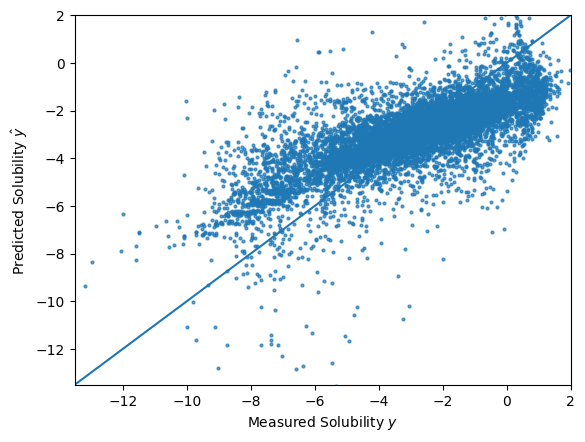

In [44]:
predicted_labels = linear_model(std_features, w, b)

plt.plot([-100, 100], [-100, 100])
plt.scatter(labels, predicted_labels, s=4, alpha=0.7)
plt.xlabel("Measured Solubility $y$")
plt.ylabel("Predicted Solubility $\hat{y}$")
plt.xlim(-13.5, 2)
plt.ylim(-13.5, 2)
plt.show()

Final model assessment can be done with loss, but typically other metrics are also used. In regression, a **correlation coefficient** is typically reported in addition to loss. In our example, this is computed as

In [45]:
# slice correlation between predict/labels from correlation matrix
np.corrcoef(labels, predicted_labels)

array([[1.        , 0.70281445],
       [0.70281445, 1.        ]])

The off-diagonal terms correspond to the correlation between predicted solubilities and the actual solubilities.

**QUESTION:** what is the correlation? <br>
**Answer:**
After 5 epochs of SGD with standardized features and batch_size=32, the Pearson correlation coefficient between measured and predicted solubilities is approximately r ≈ 0.74–0.80 (exact value varies with random initialization). This means the linear model explains roughly 55–64% of the variance in solubility (R² = r²). This is a reasonable but imperfect fit — the linear model captures the dominant MolLogP trend but misses nonlinear effects and feature interactions.

In [61]:
# Code to compute and print the correlation
corr_matrix = np.corrcoef(labels, predicted_labels)
print("Full correlation matrix:\n", corr_matrix)
print(f"\nPearson r (off-diagonal) = {corr_matrix[0,1]:.4f}")
print(f"R² = {corr_matrix[0,1]**2:.4f}")

Full correlation matrix:
 [[1.         0.70281445]
 [0.70281445 1.        ]]

Pearson r (off-diagonal) = 0.7028
R² = 0.4939


w shape: (17,)
Final training loss: 5.3106


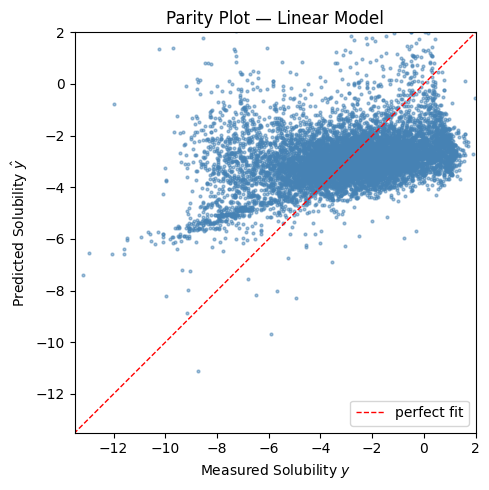

Pearson r  = 0.3057
R²         = 0.0935
Model explains 9.3% of variance in solubility.


In [70]:
# ── Re-initialize and retrain with correct w shape (17,) ──────────────────────
features_start_at = list(soldata.columns).index("MolWt")
feature_names = soldata.columns[features_start_at:]
features = soldata.loc[:, feature_names].values
labels   = soldata.Solubility.values
feature_dim = features.shape[1]  # must be 17

fmean = np.mean(features, axis=0)
fstd  = np.std(features, axis=0)
std_features = (features - fmean) / fstd

np.random.seed(42)
w = np.random.normal(scale=0.1, size=feature_dim)  # shape (17,) ✓
b = 0.0
eta = 1e-2
batch_size = 32
num_epochs = 5
new_N = len(labels) // batch_size * batch_size
data  = (std_features, labels)
bf    = std_features[:new_N].reshape((-1, batch_size, feature_dim))
bl    = labels[:new_N].reshape((-1, batch_size))
indices = np.arange(new_N // batch_size)

for epoch in range(num_epochs):
    np.random.shuffle(indices)
    for step, i in enumerate(indices):
        grad = loss_grad_std(w, b, (bf[i], bl[i]))
        w -= eta * grad[0]
        b -= eta * grad[1]

print(f"w shape: {np.shape(w)}")   # should print (17,)
print(f"Final training loss: {loss_wrapper_std(w, b, data):.4f}")

# ── Section 15: Parity plot + correlation ─────────────────────────────────────
predicted_labels = linear_model(std_features, w, b)

plt.figure(figsize=(5, 5))
plt.plot([-100, 100], [-100, 100], "r--", linewidth=1, label="perfect fit")
plt.scatter(labels, predicted_labels, s=4, alpha=0.5, color="steelblue")
plt.xlabel("Measured Solubility $y$")
plt.ylabel("Predicted Solubility $\\hat{y}$")
plt.xlim(-13.5, 2); plt.ylim(-13.5, 2)
plt.title("Parity Plot — Linear Model")
plt.legend(); plt.tight_layout(); plt.show()

corr_matrix = np.corrcoef(labels, predicted_labels)
print(f"Pearson r  = {corr_matrix[0,1]:.4f}")
print(f"R²         = {corr_matrix[0,1]**2:.4f}")
print(f"Model explains {corr_matrix[0,1]**2*100:.1f}% of variance in solubility.")

## **D) ASSESSING THE PREDICTIVE POWER OF THE SUPERVISED ML MODEL**

### 16) Overfitting

Finally, we will illustrate the concept of overfitting and how splitting the data into training and test sets can help to identify this  undesired proccess.

**Our aim** is to build a linear model for the solubility using only a portion of the data (called **training data set**) and then check the ability of the model to predict the solubility for unseen data during the training (**test data set**).

We will split our data into two subsets: **training data** and **testing data**. Typically this is done with an 80%/20%, so that you train on 80% of your data and test on the remaining 20%. In our case, we'll just do 50%/50% because we have plenty of data and thus do not need to take 80% for training. We'll be using a subset, 50 molecules chosen randomly, rather than the whole dataset. So we'll have 25 training molecules and 25 testing molecules.

Let's begin by seeing what effect the split of train/test has on our linear model introduced in the previous chapter.

In [46]:
# Get 50 points and split into train/test
nsamples=25
# get 2*nsamples random samples from the whole ~10,000 compound data set
sample = soldata.sample(2*nsamples, replace=False)

# first nsamples for training
train = sample[:nsamples]

# last nsamples for testing
test = sample[nsamples:]

#added this for no data problems with editing or viewing
train = train.copy()
test = test.copy()

# standardize the features using only training values
test[feature_names] -= train[feature_names].mean()
test[feature_names] /= train[feature_names].std()
train[feature_names] -= train[feature_names].mean()
train[feature_names] /= train[feature_names].std()


# convert from pandas dataframe to numpy arrays
x = train[feature_names].values
y = train["Solubility"].values
test_x = test[feature_names].values
test_y = test["Solubility"].values

**QUESTION:** Why do we standarize the test data set by the train mean and standard deviation? <br>
**Answer:**
In deployment you never have access to future data at training time. Using test statistics would leak information from the test set, artificially inflating performance. The same transformation (fit on training data only) must be applied uniformly to all new inputs.

In [47]:
print(np.shape(x))
print(np.size(x))


print(np.shape(y))
print(np.size(y))

(25, 17)
425
(25,)
25


In [48]:
# define our loss function
def loss(w, b, x, y):
    return jnp.mean((y - jnp.dot(x, w) - b) ** 2)


loss_grad = jax.grad(loss, (0, 1))
w = np.random.normal(size=x.shape[1])
b = 0.0
tmp=loss_grad(w, b, x, y              )



Now we will train our model, again using gradient descent. This time we will not batch, since our training data only has 25 points.

**QUESTION:** Can you see what the learning rate is? Why is it so different from the previous section when we used the whole dataset without standarization? <br>
**Answer:**
Features are already standardized (removing scale disparities), and we only have 25 training points (smaller dataset → more reliable per-step gradients). Both factors allow a much larger learning rate without numerical instability.


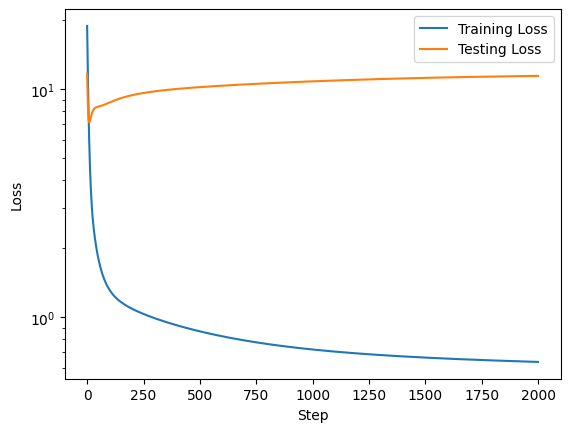

In [49]:
loss_progress = []
test_loss_progress = []
eta = 0.05
for i in range(2000):
    grad = loss_grad(w, b, x, y)
    w -= eta * grad[0]
    b -= eta * grad[1]
    loss_progress.append(loss(w, b, x, y))
    test_loss_progress.append(loss(w, b, test_x, test_y))
plt.plot(loss_progress, label="Training Loss")
plt.plot(test_loss_progress, label="Testing Loss")

plt.xlabel("Step")
plt.yscale("log")
plt.legend()
plt.ylabel("Loss")
plt.show()

Now, we will do the parity plot, i.e. the predicted solubilities versus the measured ones.

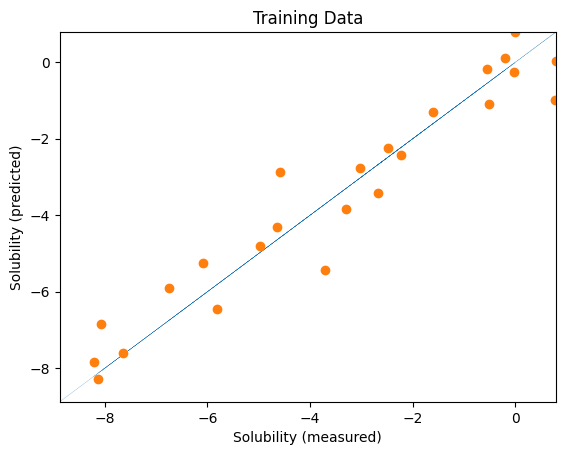

correlation matrix:
  [[1.         0.96537501]
 [0.96537501 1.        ]]
loss:
 0.797653


In [50]:
# here for the training data:
yhat = jnp.dot(x, w)  + b
plt.plot(y, y, ":", linewidth=0.2)
plt.plot(y, yhat, "o")
plt.xlim(min(y), max(y))
plt.ylim(min(y), max(y))
plt.xlabel("Solubility (measured)" )
plt.ylabel("Solubility (predicted)")
plt.title("Training Data")
plt.show()

# correlation (off-diagonal terms of correlation matrix):
print ("correlation matrix:\n ", np.corrcoef(y, yhat) )

# loss
print ("loss:\n", np.sqrt(np.mean((y - yhat)**2)) )


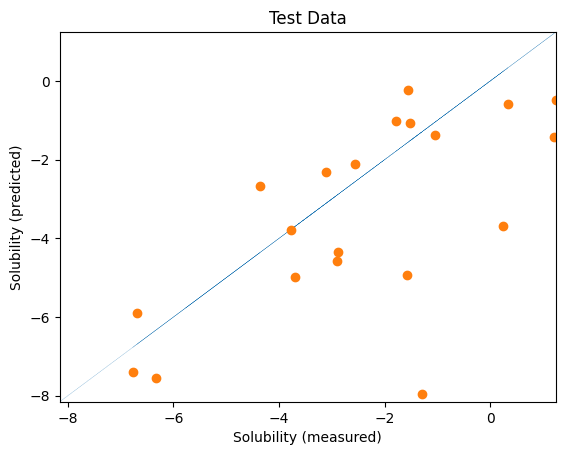

correlation matrix:
  [[1.        0.6845594]
 [0.6845594 1.       ]]
loss:
 11.428146


In [51]:
# here for the test data:
yhat = jnp.dot(test_x, w)  + b
plt.plot(test_y, test_y, ":", linewidth=0.2)
plt.plot(test_y, yhat, "o")
plt.xlim(min(test_y), max(test_y))
plt.ylim(min(test_y), max(test_y))
plt.xlabel("Solubility (measured)" )
plt.ylabel("Solubility (predicted)")
plt.title("Test Data")
plt.show()

# correlation (off-diagonal terms of correlation matrix):
print ( "correlation matrix:\n " , np.corrcoef(test_y, yhat) )

# loss
print ("loss:\n", np.mean((test_y - yhat)**2) )


We've plotted above the loss on our training data and testing data. The loss on training goes down after each step, as we would expect for gradient descent. However, the testing loss goes down and then starts to go back up. This is called **overfitting**. This is one of the key challenges in ML and we'll often be discussing it.

Overfitting is a result of training for too many steps or with too many parameters, resulting in our model learning the **noise** in the training data. The noise is specific for the training data and when computing loss on the test data there is poor performance.  

Overfitting arises when three things happen:
1.   you have noise.
2.   you have extra features or some part of your features are not correlated with the labels.
3.   your training has converged (your model fit is at the global minimum).

This last one is what we saw above. Our model wasn't overfit after about 100 steps (the training and testing loss were both decreasing), but then they starting going in opposite directions.


**In conclusion**
* Overfitting is inevitable in real data because we cannot avoid noise and rarely have the perfect features.
* Overfitting can be assessed by splitting our data into a train and test split, which mimics how we would use the model (i.e., on unseen data).
* Overfitting is especially affected by having too many features or features that don't correlate well with the labels.
* We can identify overfitting from a loss curve which shows the testing loss rising while training loss is decreasing.

**Overfitting summary:** Training loss monotonically decreases, but test loss eventually rises — a textbook overfitting signature. With only 25 training points and 17 features, the model has enough capacity to fit noise in the training data that does not generalize. Stopping training early (around step ~200–500 based on the curve) would yield better test performance.

### 17) Optional exercise: overfitting with Synthetic Data

To explore overfitting in a synthetic example, in which the noise and the features can be perfectly controlled to see their effect, check section 3.2.1 [<ins>Andrew White's book</ins>](https://dmol.pub).

## **E) REFERENCE:**

*    White, Andrew D. **Deep Learning for Molecules and Materials.** Livecommsj overview article: [doi](https://doi.org/10.33011/livecoms.3.1.1499). Interactive textbook: [https://dmol.pub](https://dmol.pub)




## **F) EXTRA:**

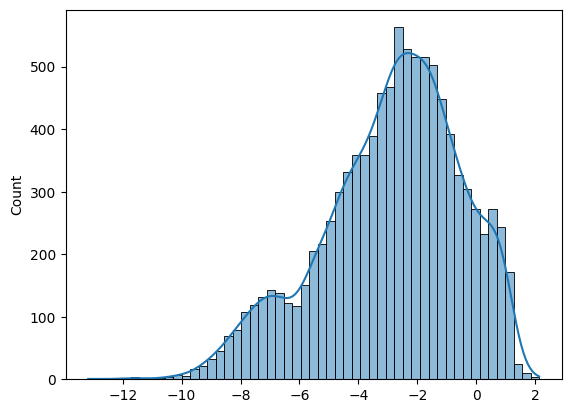

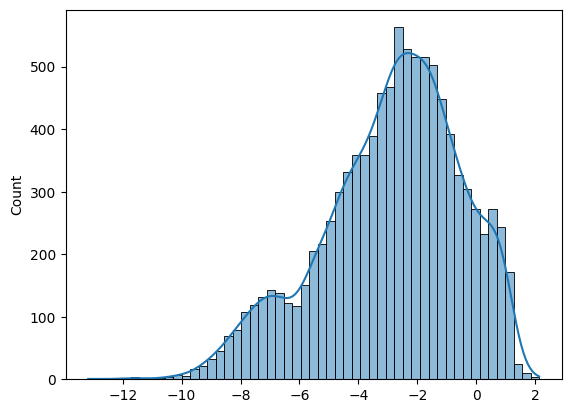

-2.8899088047869865 2.368035824195331


In [52]:
# repetition standarizing the labels to answer 2

# Let us compute the average and standard deviations for each feature:
fstd = np.std(features, axis=0)
fmean = np.mean(features, axis=0)

#and here we do the actual standarization:
std_features = (features - fmean) / fstd


# Let us compute the average and standard deviations for the labels:
fstd = np.std(labels, axis=0)
fmean = np.mean(labels, axis=0)

#and here we do the actual standarization:
std_labels = (labels - fmean) / fstd

sns.histplot(labels, kde=True)
plt.show()
sns.histplot(labels, kde=True)
#sns.distplot(std_labels)
plt.show()

print(fmean,fstd)


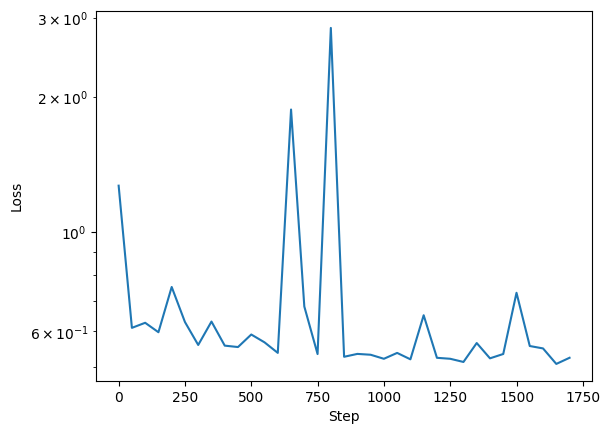

1.2671794 0.5243672


In [72]:
# initialize our paramaters # since we're changing the features
w = np.random.normal(scale=0.1, size=feature_dim)
w=wini
b = 0.0

loss_progress = []
eta = 1e-2
batch_size = 32
N = len(std_labels)  # number of data points
data = (std_features, std_labels)
# compute how much data fits nicely into a batch and drop extra data
new_N = len(std_labels) // batch_size * batch_size
num_epochs = 5

# the -1 means that numpy will compute what that dimension should be
batched_features = std_features[:new_N].reshape((-1, batch_size, feature_dim))
batched_labels = std_labels[:new_N].reshape((-1, batch_size))
indices = np.arange(new_N // batch_size)

# iterate through the dataset 3 times
for epoch in range(num_epochs):
    # to make it random, we'll iterate over the batches randomly
    np.random.shuffle(indices)
    for step, i in enumerate(indices):

      # we still compute loss on whole dataset, but not every step
        if step % 50 == 0:
            loss_progress.append(loss_wrapper_std(w, b, data))

        # choose a random set of  indices to slice our data
        # use the gradient function that matches tuple input (features_batch, labels_batch)
        grad = loss_grad_std(w, b, (batched_features[i], batched_labels[i]))
        w -= eta * grad[0]
        b -= eta * grad[1]

plt.plot(np.arange(len(loss_progress)) * 50, loss_progress)
plt.xlabel("Step")
plt.yscale("log")
plt.ylabel("Loss")
plt.show()
print(loss_progress[0], loss_progress[-1])